# Data Preparation 
**Tujuan:** Membersihkan data, melakukan preprocessing teks, pelabelan Lexicon, ekstraksi fitur TF-IDF, dan menyiapkan data latih/uji dengan SMOTE.

---

## Import Library

In [1]:
import nltk
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

True

>Digunakan di Laptop Fadel karena mengalami Error SSL: CERTIFICATE_VERIFY_FAILED

In [2]:
import pandas as pd
import numpy as np
import re
import string
import os
import pickle
import joblib
import warnings
import nltk
warnings.filterwarnings('ignore')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Imbalance & Splitting
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

## Load Dataset Mentah

In [3]:
DATA_PATH = '../2-Data-Understanding/ulasan_bummitani.csv'
OUTPUT_DIR = '.'

df_raw = pd.read_csv(DATA_PATH)
print(f'Dataset mentah dimuat: {df_raw.shape[0]} baris, {df_raw.shape[1]} kolom')
df_raw.head(3)

Dataset mentah dimuat: 499 baris, 6 kolom


,No,Username,Rating,Waktu,Ulasan Text,Variasi
0,1,t*****a,5,2022-08-28 16:48,Kualitas: bagus Cocok Untuk: boluu Nyampenya c...,-
1,2,t*****9,5,2022-03-17 19:32,Jenis: tepung ketan hitam Harga: murah Kualita...,-
2,3,a*****2,5,2025-07-07 20:01,Rasa: enak Tekstur: normal seperti tepung keta...,-


## Pembersihan Data Awal

In [4]:
df = df_raw.copy()

# Pilih hanya kolom yang relevan
df = df[['Ulasan Text']].copy()
df.columns = ['ulasan']

print(f'Jumlah data awal : {len(df)}')

# Hapus missing values 
df.dropna(subset=['ulasan'], inplace=True)
print(f'Setelah hapus NaN: {len(df)}')

# Hapus ulasan yang hanya berisi angka/simbol/kosong 
df = df[df['ulasan'].astype(str).str.strip().str.len() > 5]
print(f'Setelah hapus terlalu pendek: {len(df)}')

# Hapus duplikat 
df.drop_duplicates(subset=['ulasan'], inplace=True)
print(f'Setelah hapus duplikat: {len(df)}')

# Reset index
df.reset_index(drop=True, inplace=True)
print(f'\nData bersih: {len(df)} baris tersisa.')

Jumlah data awal : 499
Setelah hapus NaN: 499
Setelah hapus terlalu pendek: 497
Setelah hapus duplikat: 491

Data bersih: 491 baris tersisa.


## Text Preprocessing

Langkah-langkah:
1. **Case Folding** — Ubah semua huruf menjadi huruf kecil
2. **Cleaning** — Hapus karakter non-alfabet, URL, angka, emoji
3. **Normalisasi** — Perbaiki kata-kata slang/tidak baku
4. **Tokenizing** — Pisah teks menjadi token kata
5. **Stopword Removal** — Hapus kata-kata tidak bermakna
6. **Stemming** — Ubah kata ke bentuk dasar (menggunakan Sastrawi)

In [5]:
# ============================================================
# Kamus Normalisasi (kata tidak baku → kata baku)
# Tambahkan entri sesuai temuan di data Anda
# ============================================================
normalisasi_dict = {
    'baguss': 'bagus', 'bagussss': 'bagus', 'baguuuus': 'bagus',
    'enakk': 'enak', 'enakkkk': 'enak', 'enaakkk': 'enak',
    'murahh': 'murah', 'murahhh': 'murah',
    'cepett': 'cepat', 'cepett': 'cepat', 'gercep': 'cepat',
    'oke': 'baik', 'okee': 'baik', 'oks': 'baik',
    'mantap': 'bagus', 'mantul': 'bagus', 'mantapp': 'bagus', 'mantappp': 'bagus',
    'rekomended': 'direkomendasikan', 'recommended': 'direkomendasikan', 'recomen': 'direkomendasikan',
    'packing': 'kemasan', 'packingnya': 'kemasannya', 'packingan': 'kemasan',
    'seller': 'penjual', 'shopee': '',
    'tq': 'terima kasih', 'thx': 'terima kasih', 'thanks': 'terima kasih', 'makasih': 'terima kasih',
    'mkasih': 'terima kasih', 'tks': 'terima kasih',
    'gak': 'tidak', 'ga': 'tidak', 'ngga': 'tidak', 'nggak': 'tidak', 'g': 'tidak',
    'bgt': 'banget', 'bgtt': 'banget',
    'sy': 'saya', 'aku': 'saya',
    'udah': 'sudah', 'udh': 'sudah',
    'blm': 'belum', 'blom': 'belum',
    'krn': 'karena', 'karna': 'karena',
    'lg': 'lagi', 'lgi': 'lagi',
    'yg': 'yang',
    'dgn': 'dengan', 'dg': 'dengan',
    'spt': 'seperti',
    'sdh': 'sudah', 'sdg': 'sedang',
    'hrs': 'harus',
    'kl': 'kalau', 'klo': 'kalau', 'klu': 'kalau',
    'tp': 'tetapi', 'tpi': 'tetapi',
    'jg': 'juga', 'jga': 'juga',
    'dr': 'dari', 'dlm': 'dalam',
    'utk': 'untuk', 'tuk': 'untuk',
    'brg': 'barang', 'brng': 'barang',
    'pake': 'pakai', 'pk': 'pakai',
    'gimana': 'bagaimana', 'gmn': 'bagaimana',
    'produk': 'produk', 'item': 'barang',
    'lumer': 'lembut', 'lembutttt': 'lembut',
    'hitam': 'hitam', 'pekat': 'pekat',
    'tepung': 'tepung', 'ketan': 'ketan',
    'bolu': 'bolu', 'kue': 'kue',
    'wow': 'bagus', 'keren': 'bagus', 'top': 'bagus', 'top markotop': 'sangat bagus',
    'jelek': 'buruk', 'rusak': 'rusak', 'bocor': 'bocor', 'sobek': 'sobek',
    'kecewa': 'kecewa', 'buruk': 'buruk',
    'enak banget': 'sangat enak', 'enak bgt': 'sangat enak',
}

print(f'{len(normalisasi_dict)} entri')

94 entri


In [6]:
# ============================================================
# Inisialisasi Sastrawi Stemmer
# ============================================================
factory = StemmerFactory()
stemmer = StemmerFactory().create_stemmer()

# Stopwords Indonesia
stop_words_id = set(stopwords.words('indonesian'))
# Tambahkan stopwords kustom yang tidak relevan untuk sentimen
custom_stopwords = {
    'seller', 'shopee', 'kurir', 'tokopedia', 'marketplace',
    'update', 'penilaian', 'baru', 'sampai', 'terima', 'kasih',
    'pesanan', 'paket', 'barang', 'beli', 'order', 'produk',
    'kak', 'kakak', 'min', 'kak', 'bang', 'bung', 'mas', 'mbak',
    'ya', 'yah', 'sih', 'deh', 'dong', 'nih', 'loh', 'lah',
    'aja', 'ajaa', 'jga', 'blm', 'belum', 'mau', 'buat', 'bikin',
    'udah', 'udh', 'sdh', 'sudah', 'jadi', 'tapi',
    'selalu', 'semua', 'lebih', 'paling', 'sangat', 'banget',
    'dari', 'untuk', 'dengan', 'yang', 'dan', 'di', 'ke', 'pada',
    'lagi', 'juga', 'tidak', 'ada', 'ini', 'itu',
    'alhamdulillah', 'insyaallah', 'semoga', 'aamiin',
    'next', 'repeat', 'kali', 'pertama', 'kedua',
}
stop_words_id.update(custom_stopwords)

In [7]:
# ============================================================
# Fungsi Preprocessing Lengkap
# ============================================================

def case_folding(text):
    """Ubah semua huruf menjadi lowercase."""
    return str(text).lower()

def cleaning(text):
    """Hapus URL, angka, karakter khusus, emoji, dan spasi berlebih."""
    # Hapus URL
    text = re.sub(r'http\S+|www\S+', '', text)
    # Hapus mention & hashtag
    text = re.sub(r'@\w+|#\w+', '', text)
    # Hapus emoji (karakter non-ASCII)
    text = text.encode('ascii', 'ignore').decode('ascii')
    # Hapus angka
    text = re.sub(r'\d+', '', text)
    # Hapus tanda baca
    text = re.sub(r'[^\w\s]', ' ', text)
    # Hapus underscore
    text = re.sub(r'_', ' ', text)
    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def normalisasi(text):
    """Normalisasi kata tidak baku menggunakan kamus normalisasi."""
    words = text.split()
    normalized = [normalisasi_dict.get(w, w) for w in words]
    return ' '.join(normalized).strip()

def tokenizing(text):
    """Tokenisasi teks menjadi list kata."""
    return word_tokenize(text)

def remove_stopwords(tokens):
    """Hapus stopwords dari list token."""
    return [t for t in tokens if t not in stop_words_id and len(t) > 1]

def stemming(tokens):
    """Stemming menggunakan Sastrawi."""
    return [stemmer.stem(t) for t in tokens]

def preprocessing_pipeline(text):
    """Pipeline preprocessing lengkap, mengembalikan string."""
    text = case_folding(text)
    text = cleaning(text)
    text = normalisasi(text)
    tokens = tokenizing(text)
    tokens = remove_stopwords(tokens)
    tokens = stemming(tokens)
    return ' '.join(tokens)

In [8]:
# Uji fungsi pada 1 teks contoh
contoh = "Barang bagus banget! Pengirimannya cepett, packing aman. Seller amanah, next order lagi ya kak 👍"
print(f'Input  : {contoh}')
print(f'Output : {preprocessing_pipeline(contoh)}')

Input  : Barang bagus banget! Pengirimannya cepett, packing aman. Seller amanah, next order lagi ya kak 👍
Output : bagus kirim cepat kemas aman jual amanah


In [9]:
# Terapkan preprocessing ke seluruh dataset (ini mungkin membutuhkan beberapa menit)
df['ulasan_bersih'] = df['ulasan'].apply(preprocessing_pipeline)
print(f' Preprocessing selesai! {len(df)} ulasan diproses.')

# Hapus hasil yang kosong setelah preprocessing
df = df[df['ulasan_bersih'].str.strip().str.len() > 0]
df.reset_index(drop=True, inplace=True)
print(f'Data setelah hapus teks kosong: {len(df)} baris')

# Tampilkan perbandingan
df[['ulasan', 'ulasan_bersih']].head(5)

 Preprocessing selesai! 491 ulasan diproses.
Data setelah hapus teks kosong: 485 baris


,ulasan,ulasan_bersih
0,Kualitas: bagus Cocok Untuk: boluu Nyampenya c...,kualitas bagus cocok boluu nyampenya cepet eks...
1,Jenis: tepung ketan hitam Harga: murah Kualita...,jenis tepung ketan hitam harga murah kualitas ...
2,Rasa: enak Tekstur: normal seperti tepung keta...,enak tekstur normal tepung ketan guna cocok ku...
3,Rasa: enak dibuat bolu Kegunaan: buat bolu ket...,enak bolu guna bolu ketan hitam ori keju lembu...
4,Jenis: tepung ketan hitam Harga: murah Kualita...,jenis tepung ketan hitam harga murah kualitas ...


## Pelabelan menggunakan InSet Lexicon

Aturan pelabelan:
- Hitung total skor bobot kata positif dan negatif dari kamus InSet
- **Total > 0** → Label **Positif (1)**
- **Total ≤ 0** → Label **Negatif (0)**

InSet Lexicon tersedia di: https://github.com/masdevid/ID-Lexicon

In [10]:
# ============================================================
# Inset dari: https://github.com/fajri91/InSet
#   - positive.tsv : word\tweight
#   - negative.tsv : word\tweight
# ============================================================

LEXICON_POS_PATH = 'Inset/positive.tsv'
LEXICON_NEG_PATH = 'Inset/negative.tsv'

lexicon_pos = {}
lexicon_neg = {}

if os.path.exists(LEXICON_POS_PATH):
    try:
        # File memiliki header 'word' dan 'weight', gunakan header=0
        df_pos = pd.read_csv(LEXICON_POS_PATH, sep='\t', header=0)
        df_pos.columns = ['kata', 'skor']
        df_pos['skor'] = pd.to_numeric(df_pos['skor'], errors='coerce').fillna(0)
        lexicon_pos = dict(zip(df_pos['kata'], df_pos['skor']))
        print(f'Lexicon Positif dimuat: {len(lexicon_pos)} kata')
    except Exception as e:
        print(f'Gagal load lexicon positif: {e}')
else:
    print(f'File {LEXICON_POS_PATH} tidak ditemukan.')

if os.path.exists(LEXICON_NEG_PATH):
    try:
        # File memiliki header 'word' dan 'weight', gunakan header=0
        df_neg = pd.read_csv(LEXICON_NEG_PATH, sep='\t', header=0)
        df_neg.columns = ['kata', 'skor']
        df_neg['skor'] = pd.to_numeric(df_neg['skor'], errors='coerce').fillna(0)
        lexicon_neg = dict(zip(df_neg['kata'], df_neg['skor']))
        print(f'Lexicon Negatif dimuat: {len(lexicon_neg)} kata')
    except Exception as e:
        print(f'Gagal load lexicon negatif: {e}')
else:
    print(f'File {LEXICON_NEG_PATH} tidak ditemukan.')

# Gabung kedua lexicon
lexicon_all = {**lexicon_neg, **lexicon_pos}
print(f'\nTotal kamus lexicon: {len(lexicon_all)} kata')


Lexicon Positif dimuat: 3609 kata
Lexicon Negatif dimuat: 6607 kata

Total kamus lexicon: 9074 kata


In [ ]:
# ============================================================
# Fungsi Pelabelan InSet Lexicon
# ============================================================

def hitung_skor_sentimen(text):
    """Hitung total skor sentimen berdasarkan InSet Lexicon."""
    tokens = str(text).split()
    total_skor = sum(lexicon_all.get(token, 0) for token in tokens)
    return total_skor

def labeling_sentimen(text):
    """Beri label berdasarkan skor: >0 → Positif(1), <=0 → Negatif(0)."""
    skor = hitung_skor_sentimen(text)
    return 1 if skor > 0 else 0

# Terapkan ke dataset
df['skor_sentimen'] = df['ulasan_bersih'].apply(hitung_skor_sentimen)
df['label'] = df['ulasan_bersih'].apply(labeling_sentimen)
df['sentimen'] = df['label'].map({1: 'Positif', 0: 'Negatif'})

print('Pelabelan selesai.')
print('\n=== Distribusi Label ===')
label_dist = df['sentimen'].value_counts()
print(label_dist)
print(f'\nRatio Positif:Negatif = {label_dist.get("Positif",0)}:{label_dist.get("Negatif",0)}')

✅ Pelabelan selesai.

=== Distribusi Label ===
sentimen
Positif    424
Negatif     61
Name: count, dtype: int64

Ratio Positif:Negatif = 424:61


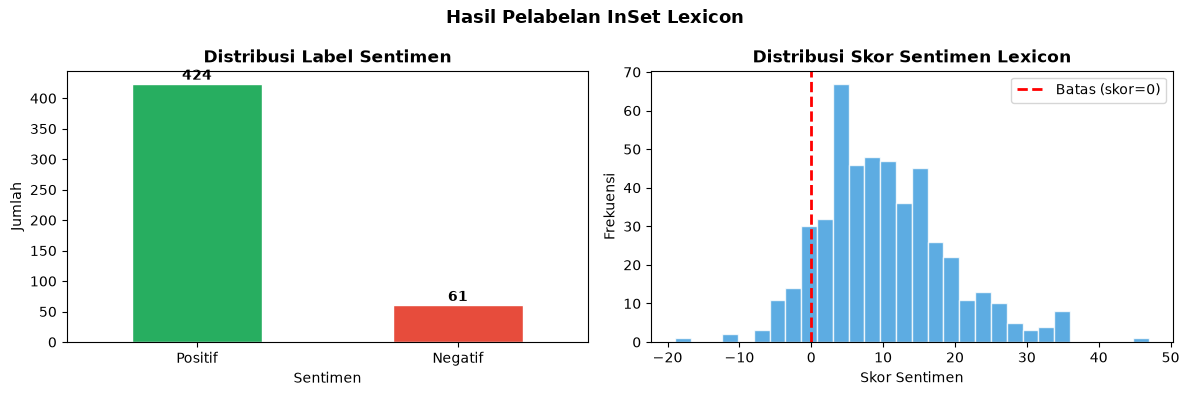

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribusi label
colors = ['#27AE60', '#E74C3C']
label_dist.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', rot=0)
axes[0].set_title('Distribusi Label Sentimen', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentimen')
axes[0].set_ylabel('Jumlah')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                 str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')

# Distribusi skor
axes[1].hist(df['skor_sentimen'], bins=30, color='#3498DB', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Batas (skor=0)')
axes[1].set_title('Distribusi Skor Sentimen Lexicon', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Skor Sentimen')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.suptitle('Hasil Pelabelan InSet Lexicon', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Tampilkan contoh per kelas
print('Contoh Ulasan POSITIF')
for _, row in df[df['label'] == 1].head(3).iterrows():
    print(f'  Skor: {row["skor_sentimen"]:+d} | {row["ulasan_bersih"][:80]}...')

print('\nContoh Ulasan NEGATIF')
for _, row in df[df['label'] == 0].head(3).iterrows():
    print(f'  Skor: {row["skor_sentimen"]:+d} | {row["ulasan_bersih"][:80]}...')

Contoh Ulasan POSITIF
  Skor: +35 | kualitas bagus cocok boluu nyampenya cepet eksekusi hasil muas enak bolu pas mat...
  Skor: +32 | jenis tepung ketan hitam harga murah kualitas bagus tepung bolu ketan pas lebara...
  Skor: +27 | enak tekstur normal tepung ketan guna cocok kue solusi jitu biar rebut tepung ke...

Contoh Ulasan NEGATIF
  Skor: -7 | komposisi beras ketan hitam alami produksi lokal indonesia...
  Skor: -5 | dbikin bolu ketan hitam hsilx bolu hitam pekat enk tektur kasar paking rapi...
  Skor: +0 | lwzat tekstur lembut guna kueee enak qangiii lagi ragu oder gusyyyy juhartiyah...


## Simpan Data Bersih ke CSV

In [ ]:
# Simpan dataset yang sudah dilabeli
ulasan_bersih_path = os.path.join(OUTPUT_DIR, 'ulasan_bersih.csv')
df.to_csv(ulasan_bersih_path, index=False)
print(f' Dataset bersih disimpan: {ulasan_bersih_path}')
print(df[['ulasan', 'ulasan_bersih', 'skor_sentimen', 'sentimen']].head())

✅ Dataset bersih disimpan: ./ulasan_bersih.csv
                                              ulasan  \
0  Kualitas: bagus Cocok Untuk: boluu Nyampenya c...   
1  Jenis: tepung ketan hitam Harga: murah Kualita...   
2  Rasa: enak Tekstur: normal seperti tepung keta...   
3  Rasa: enak dibuat bolu Kegunaan: buat bolu ket...   
4  Jenis: tepung ketan hitam Harga: murah Kualita...   

                                       ulasan_bersih  skor_sentimen sentimen  
0  kualitas bagus cocok boluu nyampenya cepet eks...             35  Positif  
1  jenis tepung ketan hitam harga murah kualitas ...             32  Positif  
2  enak tekstur normal tepung ketan guna cocok ku...             27  Positif  
3  enak bolu guna bolu ketan hitam ori keju lembu...             10  Positif  
4  jenis tepung ketan hitam harga murah kualitas ...             36  Positif  


## Feature Extraction — TF-IDF

In [ ]:
# Inisialisasi TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,    # Batasi fitur agar tidak terlalu sparse
    ngram_range=(1, 2),   # Unigram + Bigram
    min_df=2,             # Kata harus muncul minimal di 2 dokumen
    sublinear_tf=True     # Gunakan log(tf) untuk mengurangi dominasi frekuensi tinggi
)

X = tfidf_vectorizer.fit_transform(df['ulasan_bersih'])
y = df['label'].values

print(f'TF-IDF berhasil dibuat.')
print(f'   → Jumlah sampel  : {X.shape[0]}')
print(f'   → Jumlah fitur   : {X.shape[1]}')
print(f'\nTop 20 fitur TF-IDF:')
feature_names = tfidf_vectorizer.get_feature_names_out()
print(list(feature_names[:20]))

✅ TF-IDF berhasil dibuat.
   → Jumlah sampel  : 485
   → Jumlah fitur   : 801

Top 20 fitur TF-IDF:
['abang', 'abu', 'admin', 'adon', 'adon kue', 'after', 'alhamdulilah', 'alhamdulilah paket', 'all', 'aman', 'aman bocor', 'aman cepat', 'aman harga', 'aman kemas', 'aman lengkap', 'aman pakai', 'aman sesuai', 'aman terimakasih', 'aman tuju', 'amanah']


## Train-Test Split (80:20)

In [ ]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y   # Pertahankan proporsi kelas
)

print(f' Data dibagi (80:20):')
print(f'   → X_train  : {X_train.shape}')
print(f'   → X_test   : {X_test.shape}')
print(f'   → y_train  : {y_train.shape} | Positif: {y_train.sum()}, Negatif: {(y_train==0).sum()}')
print(f'   → y_test   : {y_test.shape}  | Positif: {y_test.sum()}, Negatif: {(y_test==0).sum()}')

✅ Data dibagi (80:20):
   → X_train  : (388, 801)
   → X_test   : (97, 801)
   → y_train  : (388,) | Positif: 339, Negatif: 49
   → y_test   : (97,)  | Positif: 85, Negatif: 12


## Oversampling dengan SMOTE

In [17]:
# SMOTE hanya diterapkan pada DATA LATIH (bukan data uji!)
min_class_count = min(y_train.sum(), (y_train == 0).sum())
k_neighbors = min(5, min_class_count - 1)  # Hindari error jika kelas kecil

smote = SMOTE(
    random_state=RANDOM_STATE,
    k_neighbors=max(1, k_neighbors)
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f'SMOTE selesai diterapkan pada data latih:')
print(f'   → Sebelum SMOTE: {X_train.shape[0]} sampel')
print(f'   → Sesudah SMOTE: {X_train_smote.shape[0]} sampel')
print(f'   → Distribusi y_train_smote: Positif={y_train_smote.sum()}, Negatif={(y_train_smote==0).sum()}')

SMOTE selesai diterapkan pada data latih:
   → Sebelum SMOTE: 388 sampel
   → Sesudah SMOTE: 678 sampel
   → Distribusi y_train_smote: Positif=339, Negatif=339


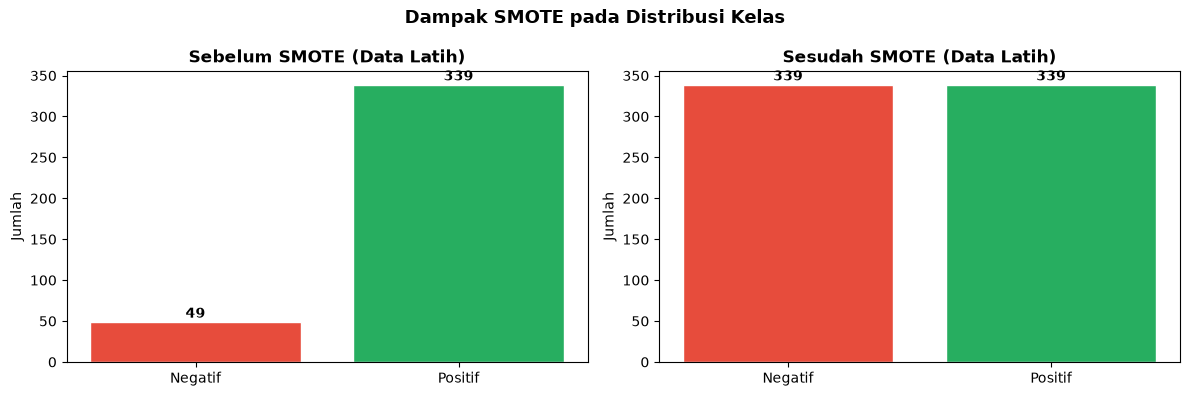

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (data, title) in zip(axes, [
    (y_train, 'Sebelum SMOTE (Data Latih)'),
    (y_train_smote, 'Sesudah SMOTE (Data Latih)'),
]):
    unique, counts = np.unique(data, return_counts=True)
    labels = ['Negatif' if u == 0 else 'Positif' for u in unique]
    colors = ['#E74C3C', '#27AE60']
    bars = ax.bar(labels, counts, color=colors[:len(unique)], edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Jumlah')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 1, str(int(h)),
                ha='center', va='bottom', fontweight='bold')

plt.suptitle('Dampak SMOTE pada Distribusi Kelas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Simpan Artefak untuk Fase Modeling

In [ ]:
import scipy.sparse

artifacts = {
    'X_train_smote.pkl': X_train_smote,
    'y_train_smote.pkl': y_train_smote,
    'X_test.pkl': X_test,
    'y_test.pkl': y_test,
    'tfidf_vectorizer.pkl': tfidf_vectorizer,
}

for filename, obj in artifacts.items():
    path = os.path.join(OUTPUT_DIR, filename)
    joblib.dump(obj, path)
    print(f' Disimpan: {path}')

print(f'\nSemua artefak berhasil disimpan di folder: {os.path.abspath(OUTPUT_DIR)}')
print('\n=== Ringkasan Artefak ===')
print(f'  X_train_smote : {X_train_smote.shape}')
print(f'  y_train_smote : {y_train_smote.shape}')
print(f'  X_test        : {X_test.shape}')
print(f'  y_test        : {y_test.shape}')
print(f'  tfidf_vectorizer : {X_train_smote.shape[1]} fitur')

  ✅ Disimpan: ./X_train_smote.pkl
  ✅ Disimpan: ./y_train_smote.pkl
  ✅ Disimpan: ./X_test.pkl
  ✅ Disimpan: ./y_test.pkl
  ✅ Disimpan: ./tfidf_vectorizer.pkl

🎉 Semua artefak berhasil disimpan di folder: /Users/xeroon/MyCode/Kuliah/DataMining/Test/Analisis_Sentimen/3-Data-Preparation

=== Ringkasan Artefak ===
  X_train_smote : (678, 801)
  y_train_smote : (678,)
  X_test        : (97, 801)
  y_test        : (97,)
  tfidf_vectorizer : 801 fitur


## Ringkasan Fase Data Preparation

| Tahap | Detail |
|-------|--------|
| Data awal | 500 ulasan |
| Setelah cleaning | Hapus NaN, duplikat, teks terlalu pendek |
| Preprocessing | Case folding → Cleaning → Normalisasi → Tokenizing → Stopword Removal → Stemming (Sastrawi) |
| Pelabelan | InSet Lexicon: skor > 0 = Positif, ≤ 0 = Negatif |
| TF-IDF | max_features=3000, ngram_range=(1,2) |
| Split | 80% latih, 20% uji (stratified) |
| SMOTE | Diterapkan pada data latih untuk menyeimbangkan kelas |

> **Artefak tersimpan:** `X_train_smote.pkl`, `y_train_smote.pkl`, `X_test.pkl`, `y_test.pkl`, `tfidf_vectorizer.pkl`, `ulasan_bersih.csv`